In [375]:
from collections import defaultdict
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_curve, precision_recall_curve, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [376]:
engagement = pd.read_csv('takehome_user_engagement.csv')

In [377]:
print (engagement.head())

            time_stamp  user_id  visited
0  2014-04-22 03:53:30        1        1
1  2013-11-15 03:45:04        2        1
2  2013-11-29 03:45:04        2        1
3  2013-12-09 03:45:04        2        1
4  2013-12-25 03:45:04        2        1


In [378]:
print(engagement.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   time_stamp  207917 non-null  object
 1   user_id     207917 non-null  int64 
 2   visited     207917 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 4.8+ MB
None


In [379]:
print(engagement.isnull().sum())

time_stamp    0
user_id       0
visited       0
dtype: int64


In [380]:
print(engagement.duplicated().sum())

0


In [381]:
print(engagement.dtypes)

time_stamp    object
user_id        int64
visited        int64
dtype: object


In [382]:
engagement['time_stamp'] = pd.to_datetime(engagement['time_stamp'])

In [383]:
print(engagement['time_stamp'].unique())

<DatetimeArray>
['2014-04-22 03:53:30', '2013-11-15 03:45:04', '2013-11-29 03:45:04',
 '2013-12-09 03:45:04', '2013-12-25 03:45:04', '2013-12-31 03:45:04',
 '2014-01-08 03:45:04', '2014-02-03 03:45:04', '2014-02-08 03:45:04',
 '2014-02-09 03:45:04',
 ...
 '2014-04-28 14:22:45', '2014-05-17 14:22:45', '2014-05-30 14:22:45',
 '2014-04-11 19:39:56', '2013-10-22 13:33:17', '2013-09-06 06:14:15',
 '2013-01-15 18:28:37', '2014-04-27 12:45:16', '2012-06-02 11:55:59',
 '2014-01-26 08:57:12']
Length: 207220, dtype: datetime64[ns]


In [384]:
print(engagement['user_id'].unique())

[    1     2     3 ... 11998 11999 12000]


In [385]:
print(engagement['visited'].unique())

[1]


<Axes: xlabel='time_stamp'>

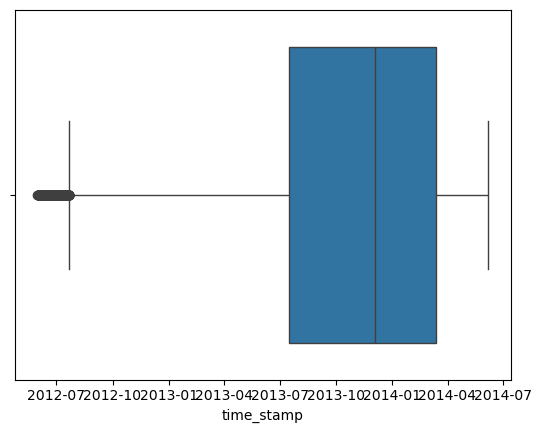

In [386]:
sns.boxplot(x=engagement['time_stamp'])

In [387]:
# Extract year from time_stamp
engagement['year'] = engagement['time_stamp'].dt.year

# Count the number of records per year
year_counts = engagement['year'].value_counts().sort_index()

print(year_counts)

year
2012     11855
2013    105725
2014     90337
Name: count, dtype: int64


##### The distribution of dates seemed odd, but I see what is happening now

In [388]:
#takehome = pd.read_csv('takehome_users.csv')   #something odd preventing this!
takehome = pd.read_csv('takehome_users.csv', encoding='ISO-8859-1') 

In [389]:
print(takehome.head())

   object_id        creation_time               name  \
0          1  2014-04-22 03:53:30     Clausen August   
1          2  2013-11-15 03:45:04      Poole Matthew   
2          3  2013-03-19 23:14:52  Bottrill Mitchell   
3          4  2013-05-21 08:09:28    Clausen Nicklas   
4          5  2013-01-17 10:14:20          Raw Grace   

                        email creation_source  last_session_creation_time  \
0    AugustCClausen@yahoo.com    GUEST_INVITE                1.398139e+09   
1      MatthewPoole@gustr.com      ORG_INVITE                1.396238e+09   
2  MitchellBottrill@gustr.com      ORG_INVITE                1.363735e+09   
3   NicklasSClausen@yahoo.com    GUEST_INVITE                1.369210e+09   
4          GraceRaw@yahoo.com    GUEST_INVITE                1.358850e+09   

   opted_in_to_mailing_list  enabled_for_marketing_drip  org_id  \
0                         1                           0      11   
1                         0                           0       1   

In [390]:
print(takehome.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  object 
 2   name                        12000 non-null  object 
 3   email                       12000 non-null  object 
 4   creation_source             12000 non-null  object 
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 937.6+ KB
None


In [391]:
print(takehome.describe())

         object_id  last_session_creation_time  opted_in_to_mailing_list  \
count  12000.00000                8.823000e+03              12000.000000   
mean    6000.50000                1.379279e+09                  0.249500   
std     3464.24595                1.953116e+07                  0.432742   
min        1.00000                1.338452e+09                  0.000000   
25%     3000.75000                1.363195e+09                  0.000000   
50%     6000.50000                1.382888e+09                  0.000000   
75%     9000.25000                1.398443e+09                  0.000000   
max    12000.00000                1.402067e+09                  1.000000   

       enabled_for_marketing_drip        org_id  invited_by_user_id  
count                12000.000000  12000.000000         6417.000000  
mean                     0.149333    141.884583         5962.957145  
std                      0.356432    124.056723         3383.761968  
min                      0.000000  

In [392]:
print(takehome.isnull().sum())

object_id                        0
creation_time                    0
name                             0
email                            0
creation_source                  0
last_session_creation_time    3177
opted_in_to_mailing_list         0
enabled_for_marketing_drip       0
org_id                           0
invited_by_user_id            5583
dtype: int64


In [393]:
print(takehome.dtypes)

object_id                       int64
creation_time                  object
name                           object
email                          object
creation_source                object
last_session_creation_time    float64
opted_in_to_mailing_list        int64
enabled_for_marketing_drip      int64
org_id                          int64
invited_by_user_id            float64
dtype: object


In [394]:
takehome['name'] = takehome['name'].astype('string')
print(takehome['object_id'].unique())

[    1     2     3 ... 11998 11999 12000]


In [395]:
takehome['email'] = takehome['email'].astype('string')
print(takehome['email'].unique())

<StringArray>
[     'AugustCClausen@yahoo.com',        'MatthewPoole@gustr.com',
    'MitchellBottrill@gustr.com',     'NicklasSClausen@yahoo.com',
            'GraceRaw@yahoo.com', 'EduardoPereiraCunha@yahoo.com',
    'TylerSewell@jourrapide.com',    'DanielleHamilton@yahoo.com',
         'PaulAmsel@hotmail.com', 'CarlaFerreiraSantos@gustr.com',
 ...
       'ArthurJVaughn@gmail.com',    'AmandaAHermansen@yahoo.com',
       'IsabelTownsend@cuvox.de',            'conxzghp@eaouk.com',
     'SebastianWerfel@gmail.com',         'SophiaMeier@gustr.com',
        'AmelieFisher@gmail.com',           'JakeHaynes@cuvox.de',
            'mhaerzxp@iuxiw.com',     'ThaisMeloLima@hotmail.com']
Length: 11980, dtype: string


In [396]:
takehome['creation_source'] = takehome['creation_source'].astype('string')
print(takehome['creation_source'].unique())

<StringArray>
[      'GUEST_INVITE',         'ORG_INVITE',             'SIGNUP',
  'PERSONAL_PROJECTS', 'SIGNUP_GOOGLE_AUTH']
Length: 5, dtype: string


In [397]:
takehome['opted_in_to_mailing_list'] = takehome['opted_in_to_mailing_list'].astype('int')
print(takehome['opted_in_to_mailing_list'].unique())
#This was originally changed to boolean, but it was interfering with the analytics I did later.  I didn't want to clear the code block entirely, so I simply have it set as 'int' again as a reminder where this took place, should I need to change it to a boolean value later.

[1 0]


In [398]:
takehome['opted_in_to_mailing_list'] = takehome['opted_in_to_mailing_list'].astype('int')
print(takehome['opted_in_to_mailing_list'].unique())
#See above note

[1 0]


In [399]:
takehome['creation_time'] = pd.to_datetime(takehome['creation_time'])
print(takehome['creation_time'].unique())

<DatetimeArray>
['2014-04-22 03:53:30', '2013-11-15 03:45:04', '2013-03-19 23:14:52',
 '2013-05-21 08:09:28', '2013-01-17 10:14:20', '2013-12-17 03:37:06',
 '2012-12-16 13:24:32', '2013-07-31 05:34:02', '2013-11-05 04:04:24',
 '2013-01-16 22:08:03',
 ...
 '2014-04-20 14:22:45', '2014-04-09 19:39:56', '2013-03-28 23:24:21',
 '2012-06-05 04:46:16', '2013-10-21 13:33:17', '2013-09-06 06:14:15',
 '2013-01-10 18:28:37', '2014-04-27 12:45:16', '2012-05-31 11:55:59',
 '2014-01-26 08:57:12']
Length: 11996, dtype: datetime64[ns]


In [400]:
takehome['last_session_creation_time'] = pd.to_datetime(takehome['last_session_creation_time'], unit='s')

print(takehome['last_session_creation_time'].unique())

<DatetimeArray>
['2014-04-22 03:53:30', '2014-03-31 03:45:04', '2013-03-19 23:14:52',
 '2013-05-22 08:09:28', '2013-01-22 10:14:20', '2013-12-19 03:37:06',
 '2012-12-20 13:24:32',                 'NaT', '2014-06-03 22:08:03',
 '2013-12-27 03:55:54',
 ...
 '2013-09-07 11:24:33', '2013-07-06 21:00:48', '2014-05-30 14:22:45',
 '2014-04-11 19:39:56', '2013-10-22 13:33:17', '2013-09-06 06:14:15',
 '2013-01-15 18:28:37', '2014-04-27 12:45:16', '2012-06-02 11:55:59',
 '2014-01-26 08:57:12']
Length: 8822, dtype: datetime64[ns]


## The values for last_session_creation_time were in seconds, which have now been converted to a proper datetime value.

In [401]:
print(takehome.dtypes)

object_id                              int64
creation_time                 datetime64[ns]
name                          string[python]
email                         string[python]
creation_source               string[python]
last_session_creation_time    datetime64[ns]
opted_in_to_mailing_list               int32
enabled_for_marketing_drip             int64
org_id                                 int64
invited_by_user_id                   float64
dtype: object


## Aside from the null values for the last_session_creation_time and invited_by_user_id, the data looks straightforward.

## I'll begin by labeling those who already qualify as "adopted"

In [402]:
adopted_user_ids = set()

for user_id, user_df in engagement.groupby('user_id'):
    dates = user_df['time_stamp'].dt.date.sort_values().unique()
    for i in range(len(dates) - 2):
        if (dates[i+2] - dates[i]).days <= 7:
            adopted_user_ids.add(user_id)
            break

In [403]:
takehome['adopted'] = takehome['object_id'].isin(adopted_user_ids).astype(int)

In [404]:
# Feature: was_invited
takehome['was_invited'] = takehome['invited_by_user_id'].notna().astype(int)

# Feature: account age (using the latest engagement timestamp as a reference)
max_engagement_date = engagement['time_stamp'].max()
takehome['account_age_days'] = (max_engagement_date - takehome['creation_time']).dt.days

# Feature: time to first activity
first_engagement = engagement.groupby('user_id')['time_stamp'].min()
takehome = takehome.merge(first_engagement.rename('first_engagement'), how='left', left_on='object_id', right_index=True)
takehome['activity_delay_days'] = (takehome['first_engagement'] - takehome['creation_time']).dt.days
takehome['activity_delay_days'] = takehome['activity_delay_days'].fillna(-1)  # -1 for users with no activity

# One-hot encode creation_source
takehome = pd.get_dummies(takehome, columns=['creation_source'], drop_first=True)

In [405]:
# Dropping columns I don't need
features = takehome.drop(columns=['object_id', 'name', 'email', 'creation_time', 'last_session_creation_time',
                                  'org_id', 'invited_by_user_id', 'first_engagement', 'adopted'])

X = features
y = takehome['adopted']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.89      0.88      2586
           1       0.21      0.18      0.20       414

    accuracy                           0.79      3000
   macro avg       0.54      0.54      0.54      3000
weighted avg       0.78      0.79      0.79      3000



### Precision (0.19): Of all users the model predicted as adopted, only 19% actually were.
### Recall (0.15): Of all actually adopted users, the model only caught 15%.
### F1 Score (0.17): Reflects poor balance between precision and recall for adopted users.

# In all, there is imbalanced classification here.
##### Checking for class balance first...

In [406]:
print(y.value_counts(normalize=True))

adopted
0    0.862
1    0.138
Name: proportion, dtype: float64


##### This explains the imbalance

In [407]:
#TO prevent boolean columns from causing problems
for col in X_train.columns:
    if X_train[col].dtype == 'boolean' or X_train[col].dtype == 'object':
        try:
            X_train[col] = X_train[col].astype(bool)
        except:
            print(f"Could not convert {col} to bool")
            
            
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [408]:
clf = RandomForestClassifier(class_weight='balanced')
clf.fit(X_resampled, y_resampled)

RandomForestClassifier(class_weight='balanced')

In [409]:
y_pred = clf.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2178  408]
 [ 303  111]]
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      2586
           1       0.21      0.27      0.24       414

    accuracy                           0.76      3000
   macro avg       0.55      0.56      0.55      3000
weighted avg       0.79      0.76      0.77      3000



##### This one only predicts the Adopted status correctly 23% of the time.
##### I'll try some threshhold tuning instead

In [410]:
y_pred_proba = clf.predict_proba(X_test)[:, 1]

In [411]:
thresholds = np.arange(0.1, 0.91, 0.05)
for thresh in thresholds:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    print(f"Threshold: {thresh:.2f} | Precision: {precision:.2f} | Recall: {recall:.2f} | F1: {f1:.2f}")

Threshold: 0.10 | Precision: 0.20 | Recall: 0.54 | F1: 0.29
Threshold: 0.15 | Precision: 0.21 | Recall: 0.47 | F1: 0.29
Threshold: 0.20 | Precision: 0.21 | Recall: 0.43 | F1: 0.28
Threshold: 0.25 | Precision: 0.20 | Recall: 0.38 | F1: 0.26
Threshold: 0.30 | Precision: 0.21 | Recall: 0.35 | F1: 0.26
Threshold: 0.35 | Precision: 0.21 | Recall: 0.32 | F1: 0.25
Threshold: 0.40 | Precision: 0.21 | Recall: 0.30 | F1: 0.25
Threshold: 0.45 | Precision: 0.21 | Recall: 0.28 | F1: 0.24
Threshold: 0.50 | Precision: 0.21 | Recall: 0.27 | F1: 0.24
Threshold: 0.55 | Precision: 0.21 | Recall: 0.25 | F1: 0.23
Threshold: 0.60 | Precision: 0.21 | Recall: 0.22 | F1: 0.22
Threshold: 0.65 | Precision: 0.22 | Recall: 0.20 | F1: 0.21
Threshold: 0.70 | Precision: 0.23 | Recall: 0.18 | F1: 0.20
Threshold: 0.75 | Precision: 0.22 | Recall: 0.15 | F1: 0.18
Threshold: 0.80 | Precision: 0.21 | Recall: 0.12 | F1: 0.15
Threshold: 0.85 | Precision: 0.20 | Recall: 0.10 | F1: 0.13
Threshold: 0.90 | Precision: 0.21 | Reca

###  A threshold of .10 seems to have the best balance between  accurately catching as many adopted users as possible, as well as more balance between precision and recall

In [412]:
best_threshold = 0.10
y_pred_best = (y_pred_proba >= best_threshold).astype(int)

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

[[1700  886]
 [ 191  223]]
              precision    recall  f1-score   support

           0       0.90      0.66      0.76      2586
           1       0.20      0.54      0.29       414

    accuracy                           0.64      3000
   macro avg       0.55      0.60      0.53      3000
weighted avg       0.80      0.64      0.70      3000



### With this threshold, we will find 50% of all adopters, but only 19% of our positive predictions will be correct.

In [413]:
y_pred_proba = clf.predict_proba(X_test)[:, 1]  # Probabilities for Adopted (class 1)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

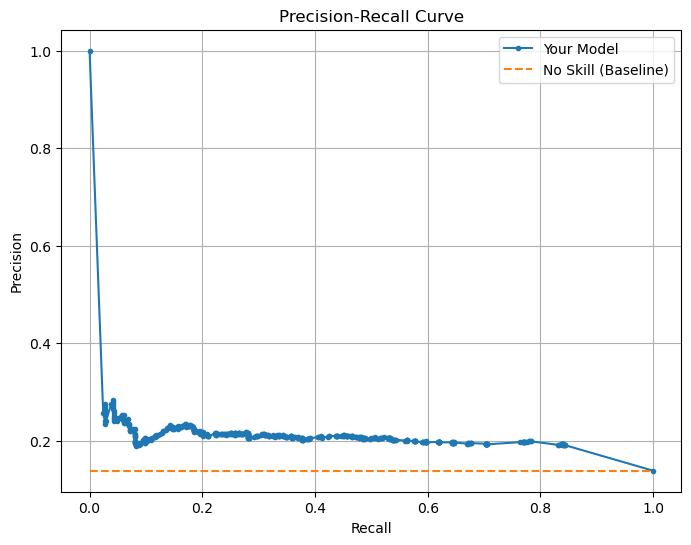

In [414]:
import matplotlib.pyplot as plt

# Plot "no skill" baseline (proportion of positive class)
no_skill = y_test.mean()

plt.figure(figsize=(8,6))
plt.plot(recall, precision, marker='.', label='Your Model')
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill (Baseline)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

##### It doesn't look like we can do much better with things as they are!

### Let's try other classifiers...

In [415]:
model = GradientBoostingClassifier()
model.fit(X_train, y_train)

GradientBoostingClassifier()

In [416]:
model = RandomForestClassifier(class_weight='balanced')

In [417]:
pipeline = Pipeline([
    ('resample', SMOTEENN()),  #SMOTE + ENN (Edited Nearest Neighbors)
    ('model', RandomForestClassifier())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('resample', SMOTEENN()), ('model', RandomForestClassifier())])

In [418]:
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]  # For precision-recall or ROC curves

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1813  773]
 [ 206  208]]
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      2586
           1       0.21      0.50      0.30       414

    accuracy                           0.67      3000
   macro avg       0.55      0.60      0.54      3000
weighted avg       0.80      0.67      0.72      3000



##### So the precision for is still quite low at .22, but recall for test 1 is up to almost .50, which is a huge improvement, as is the improvement in the class 1 score.

#### But improvement isn't up enough...I'm catching more adopted users, but also misclassifying as many non-adopted ones as adopted.

# So based on what I've found, here are the top features that help predict use adoption

                              feature  importance
3                    account_age_days    0.466257
4                 activity_delay_days    0.362397
5          creation_source_ORG_INVITE    0.043183
0            opted_in_to_mailing_list    0.029100
7              creation_source_SIGNUP    0.022444
8  creation_source_SIGNUP_GOOGLE_AUTH    0.022397
2                         was_invited    0.021612
6   creation_source_PERSONAL_PROJECTS    0.017159
1          enabled_for_marketing_drip    0.015451


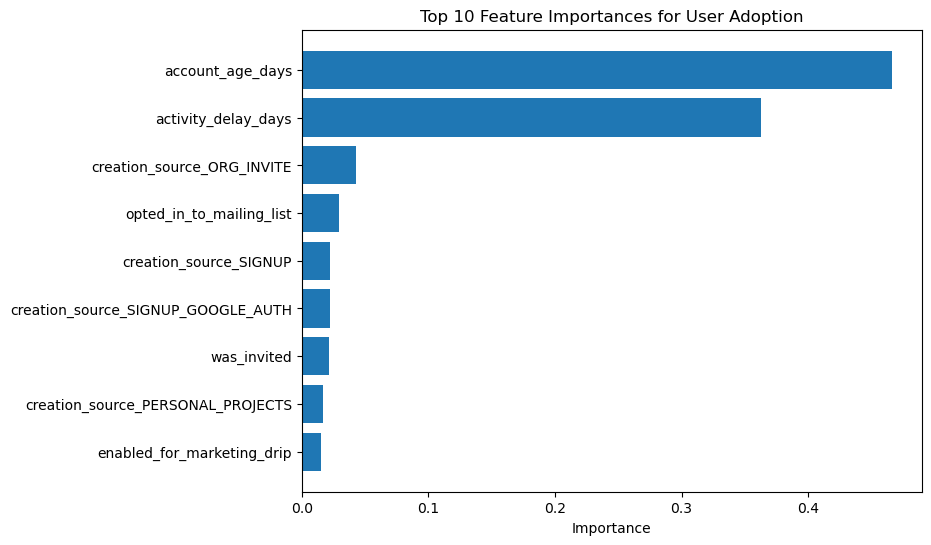

In [419]:
# Assuming 'clf' is your trained RandomForestClassifier and 'X_train' is your feature set
importances = clf.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for easy viewing
feat_imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

print(feat_imp_df.head(10))

# Plot
plt.figure(figsize=(8,6))
plt.barh(feat_imp_df['feature'][:10][::-1], feat_imp_df['importance'][:10][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances for User Adoption')
plt.show()
